<a href="https://colab.research.google.com/github/hk666890/SEM-VI--A2/blob/main/IPMV_Exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

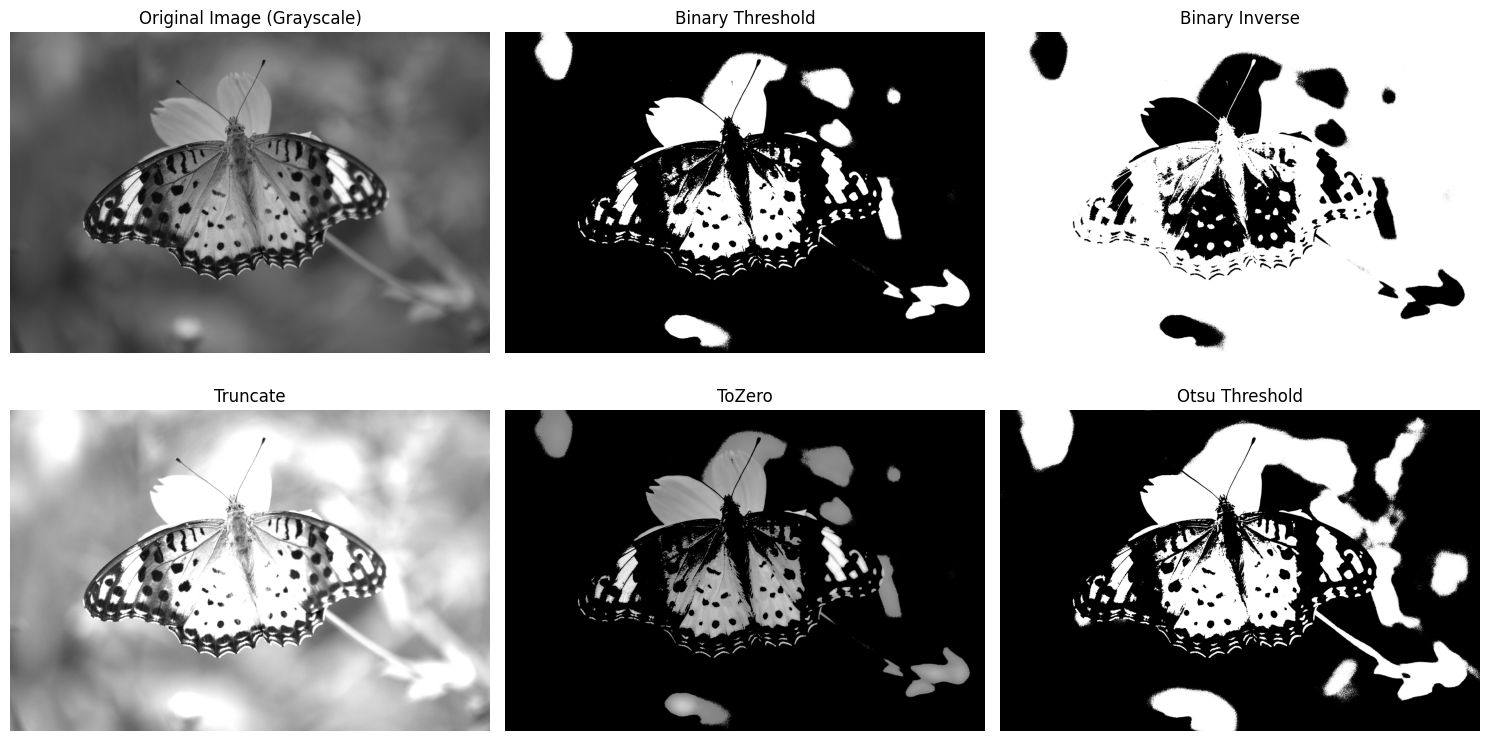

In [ ]:
import cv2
import urllib.request
import matplotlib.pyplot as plt

def apply_image_thresholding():
    # --------------------------------------------------------
    # STEP 1: Download the image
    # --------------------------------------------------------
    # New image URL provided by the user
    url = "http://upload.wikimedia.org/wikipedia/commons/7/7c/Butterfly_macro.JPG"
    image_filename = "Butterfly_macro.JPG"

    # Add a User-Agent header to avoid 403 Forbidden error
    opener = urllib.request.build_opener()
    opener.addheaders = [('User-agent', 'Mozilla/5.0')]
    urllib.request.install_opener(opener)

    try:
        urllib.request.urlretrieve(url, image_filename)
    except urllib.error.HTTPError as e:
        print(f"Error downloading image: {e}. Please check the URL or try again later.")
        return

    # Read the image. It's a color image, so we'll convert it to grayscale.
    img_color = cv2.imread(image_filename)
    if img_color is None:
        print(f"Error: Could not load image from {image_filename}. Ensure the file was downloaded correctly.")
        return

    # Convert to grayscale for thresholding
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # --------------------------------------------------------
    # STEP 2: Apply Different Thresholding Techniques
    # --------------------------------------------------------
    # Simple binary threshold
    # Pixel > 127 → white, else black
    _, binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

    # Inverse binary threshold
    _, binary_inv = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY_INV)

    # Truncate threshold
    # Pixel > 127 → 127, else unchanged
    _, trunc = cv2.threshold(img_gray, 127, 255, cv2.THRESH_TRUNC)

    # ToZero threshold
    # Pixel < 127 → 0
    _, tozero = cv2.threshold(img_gray, 127, 255, cv2.THRESH_TOZERO)

    # Otsu's Thresholding
    # Automatically finds optimal threshold
    _, otsu = cv2.threshold(img_gray, 0, 255,
                            cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # --------------------------------------------------------
    # STEP 3: Display Results
    # --------------------------------------------------------
    titles = ["Original Image (Grayscale)",
              "Binary Threshold",
              "Binary Inverse",
              "Truncate",
              "ToZero",
              "Otsu Threshold"]
    images = [img_gray, binary, binary_inv, trunc, tozero, otsu]

    plt.figure(figsize=(15, 8))
    for i in range(len(images)):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Execute the function
apply_image_thresholding()